### Memuat Dataset Kamus Bahasa Indonesia

In [2]:
import pandas as pd

# =========================================================
# MEMBACA DATASET KATA INDONESIA
# =========================================================

df = pd.read_csv("1_dataset_rnn/daftar_2000_kata_indonesia_a_z.csv")

print("=== INFORMASI DATASET ===")
print(df.head())

print("\nJumlah Data Awal:")
print(len(df))

=== INFORMASI DATASET ===
   No Huruf_Awal   Kata
0   1          A  Abadi
1   2          A   Abai
2   3          A  Abang
3   4          A   Abdi
4   5          A  Abjad

Jumlah Data Awal:
1874


### Data Cleaning dan Normalisasi Data

In [3]:
import re

# =========================================================
# AMBIL KOLOM KATA SAJA
# =========================================================

df = df[['Kata']].copy()

# =========================================================
# NORMALISASI TEKS
# =========================================================

df['Kata'] = (
    df['Kata']
    .astype(str)
    .str.lower()
    .str.strip()
)

# =========================================================
# HAPUS KARAKTER NON-HURUF
# =========================================================

df['Kata'] = df['Kata'].apply(
    lambda x: re.sub(r'[^a-zA-Z]', '', x)
)

# =========================================================
# HAPUS DATA KOSONG
# =========================================================

df = df[df['Kata'] != ""]

# =========================================================
# HAPUS DUPLIKAT
# =========================================================

df = df.drop_duplicates()

# =========================================================
# RESET INDEX
# =========================================================

df = df.reset_index(drop=True)

# =========================================================
# TAMPILKAN HASIL
# =========================================================

print("=== HASIL DATA CLEANING ===")

print(df.head())

print("\nJumlah Data Setelah Cleaning:")
print(len(df))

=== HASIL DATA CLEANING ===
    Kata
0  abadi
1   abai
2  abang
3   abdi
4  abjad

Jumlah Data Setelah Cleaning:
1864


### Pemecahan Suku Kata

In [4]:
# =========================================================
# FUNGSI PEMECAH SUKU KATA SEDERHANA
# =========================================================

vokal = "aiueo"

def pecah_suku_kata(kata):

    hasil = []
    suku = ""

    for i, huruf in enumerate(kata):

        suku += huruf

        # =================================================
        # JIKA MENEMUKAN VOKAL
        # =================================================

        if huruf in vokal:

            # Hindari index terakhir
            if i < len(kata) - 1:

                # =================================================
                # POLA:
                # vokal + konsonan + vokal
                # =================================================

                if (
                    kata[i+1] not in vokal
                    and
                    i+2 < len(kata)
                    and
                    kata[i+2] in vokal
                ):

                    hasil.append(suku)
                    suku = ""

    # =====================================================
    # SISA KARAKTER
    # =====================================================

    if suku:
        hasil.append(suku)

    return " ".join(hasil)

# =========================================================
# CONTOH HASIL PEMECAHAN SUKU KATA
# =========================================================

contoh_kata = [
    "belajar",
    "makanan",
    "berjalan",
    "pemrograman",
    "komputer"
]

print("=== HASIL GENERATOR SUKU KATA ===\n")

for kata in contoh_kata:

    hasil = pecah_suku_kata(kata)

    print(f"{kata}  -->  {hasil}")

=== HASIL GENERATOR SUKU KATA ===

belajar  -->  be la jar
makanan  -->  ma ka nan
berjalan  -->  berja lan
pemrograman  -->  pemrogra man
komputer  -->  kompu ter


### Konstruksi Suku Kata Dataset

In [5]:
# =========================================================
# MEMBANGUN DATASET NLP FINAL
# =========================================================

dataset_nlp = []

for kata in df['Kata']:

    # =====================================================
    # PECAH MENJADI SEQUENCE SUKU KATA
    # =====================================================

    sequence_suku_kata = pecah_suku_kata(kata)

    # =====================================================
    # SIMPAN KE DATASET
    # =====================================================

    dataset_nlp.append({
        "Input_Suku_Kata": sequence_suku_kata,
        "Target_Kata_Utuh": kata
    })

# =========================================================
# CONVERT MENJADI DATAFRAME
# =========================================================

df_nlp = pd.DataFrame(dataset_nlp)

# =========================================================
# TAMPILKAN HASIL
# =========================================================

print("=== HASIL DATASET NLP FINAL ===\n")

print(df_nlp.head())

print("\nJumlah Dataset NLP:")
print(len(df_nlp))

=== HASIL DATASET NLP FINAL ===

  Input_Suku_Kata Target_Kata_Utuh
0         a ba di            abadi
1           a bai             abai
2          a bang            abang
3            abdi             abdi
4           abjad            abjad

Jumlah Dataset NLP:
1864


### Menyimpan Dataset

In [6]:
# =========================================================
# MENYIMPAN HASIL DATA PREPARATION
# =========================================================

df_nlp.to_csv(
    "1_dataset_rnn/final_dataset.csv",
    index=False
)

print("✓ Dataset sequence suku kata berhasil disimpan")

print("\nLokasi Penyimpanan:")
print("1_dataset_rnn/final_dataset.csv")

✓ Dataset sequence suku kata berhasil disimpan

Lokasi Penyimpanan:
1_dataset_rnn/final_dataset.csv


### Visualisasi Dataset

   No Huruf_Awal   Kata
0   1          A  Abadi
1   2          A   Abai
2   3          A  Abang
3   4          A   Abdi
4   5          A  Abjad

Distribusi Huruf Awal:
Huruf_Awal
A    77
B    77
C    77
D    77
E    77
F    77
G    77
H    77
I    77
J    77
K    77
L    77
M    77
N    77
O    77
P    77
Q    16
R    77
S    77
T    77
U    77
V    77
W    77
X    10
Y    77
Z    77
Name: count, dtype: int64


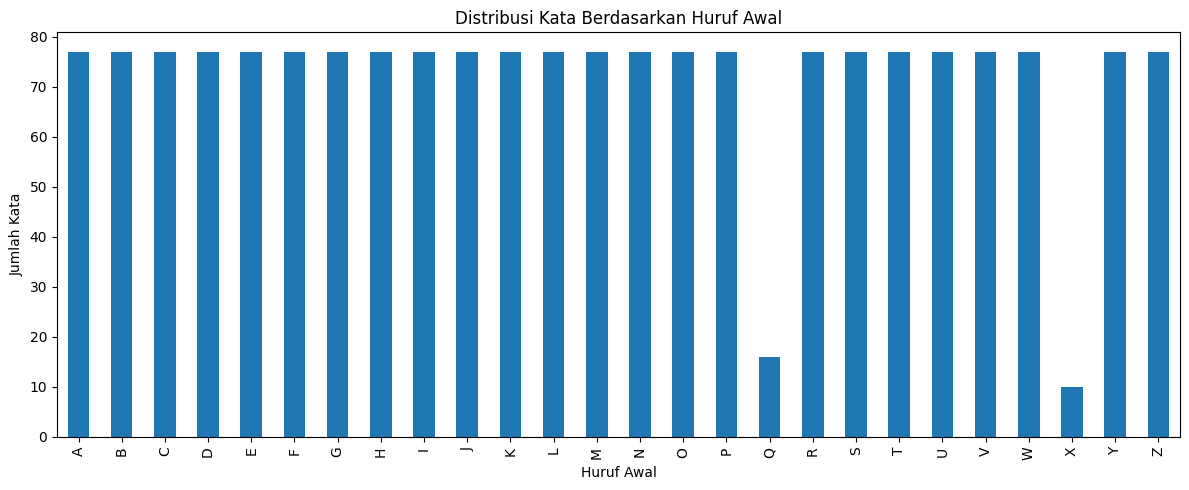

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# MEMBACA DATASET AWAL
# =====================================================

df = pd.read_csv(
    "1_dataset_rnn/daftar_2000_kata_indonesia_a_z.csv"
)

print(df.head())

# =====================================================
# HITUNG DISTRIBUSI HURUF AWAL
# =====================================================

huruf_count = (
    df['Huruf_Awal']
    .value_counts()
    .sort_index()
)

print("\nDistribusi Huruf Awal:")
print(huruf_count)

# =====================================================
# VISUALISASI
# =====================================================

plt.figure(figsize=(12,5))

huruf_count.plot(kind='bar')

plt.title('Distribusi Kata Berdasarkan Huruf Awal')
plt.xlabel('Huruf Awal')
plt.ylabel('Jumlah Kata')

plt.tight_layout()
plt.show()

=== STATISTIK PANJANG KATA ===
count    1874.000000
mean        5.408218
std         1.460041
min         2.000000
25%         5.000000
50%         5.000000
75%         6.000000
max        12.000000
Name: Panjang_Kata, dtype: float64


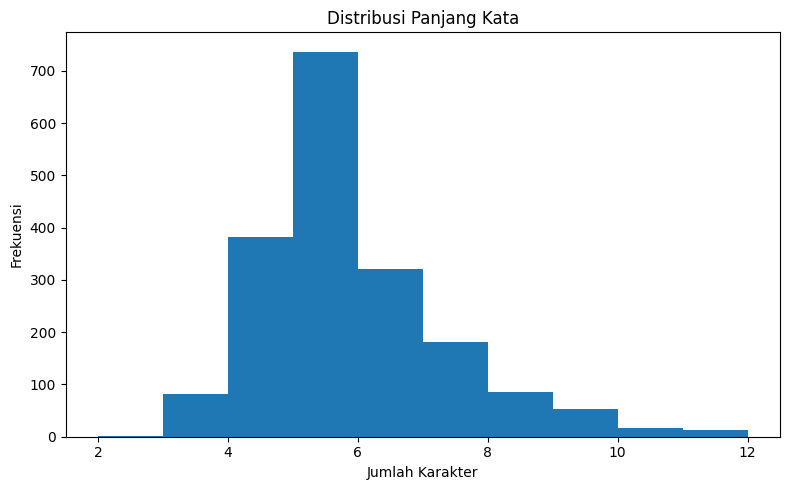

In [13]:
import matplotlib.pyplot as plt

# =====================================================
# ANALISIS PANJANG KATA
# =====================================================

df['Panjang_Kata'] = df['Kata'].str.len()

print("=== STATISTIK PANJANG KATA ===")
print(df['Panjang_Kata'].describe())

plt.figure(figsize=(8,5))

plt.hist(df['Panjang_Kata'], bins=10)

plt.title('Distribusi Panjang Kata')
plt.xlabel('Jumlah Karakter')
plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()